# 02 - Huấn luyện và So sánh

**Giai đoạn trong pipeline:** ... -> Mô hình cơ sở -> **Huấn luyện -> Giám sát -> Validation /
Lựa chọn mô hình -> Thí nghiệm** -> Đánh giá trên tập test cuối cùng -> ...

Notebook này nạp các **artifact đã lưu** từ các lần chạy chính thức (`runs/<model>/run_XXX/`)
được tạo ra bởi `scripts/train.py` - nó không huấn luyện lại bất cứ điều gì. Chúng ta so sánh:

1. `mobilenet_v2/run_002` - MobileNetV2 pretrained, batch size 32
2. `mobilenet_v2/run_003` - MobileNetV2 pretrained, batch size 64
3. `resnet18/run_001` - ResNet18 pretrained, đóng băng backbone
4. `resnet18/run_003` - ResNet18 fine-tune `layer4` và `fc`


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.visualization import plot_accuracy_curve, plot_loss_curve

RUNS = {
    "MobileNetV2 (batch 32)": PROJECT_ROOT / "runs" / "mobilenet_v2" / "run_002",
    "MobileNetV2 (batch 64)": PROJECT_ROOT / "runs" / "mobilenet_v2" / "run_003",
    "ResNet18 pretrained": PROJECT_ROOT / "runs" / "resnet18" / "run_001",
    "ResNet18 fine-tune": PROJECT_ROOT / "runs" / "resnet18" / "run_003",
}


## Bảng tổng hợp thí nghiệm

Được nạp trực tiếp từ `experiments/experiment_summary.csv`, do `scripts/compare_models.py`
tạo ra từ `config.yaml` + `metrics/final_metrics.json` thật của từng lần chạy - không có
số liệu nào ở đây được gõ tay.


In [2]:
summary_df = pd.read_csv(PROJECT_ROOT / "experiments" / "experiment_summary.csv")
summary_df

,run_id,model,description,learning_rate,batch_size,epochs,dropout,augmentation,best_epoch,best_val_loss,best_val_accuracy,test_accuracy_if_final,conclusion
0,mobilenet_v2/run_002,mobilenet_v2,mobilenet_v2_pretrained,0.0010,32,5,NaN,False,4,0.401926,0.852833,0.8512,MobileNetV2 frozen với batch size 32 là baseli...
1,mobilenet_v2/run_003,mobilenet_v2,mobilenet_v2_batch64,0.0010,64,5,NaN,False,4,0.390309,0.859500,0.8543,Chỉ tăng batch size từ 32 lên 64 giúp best val...
2,resnet18/run_001,resnet18,resnet18_pretrained,0.0010,32,5,NaN,False,5,0.375544,0.863833,0.8644,"ResNet18 frozen đạt 86.44% test accuracy, cao ..."
3,resnet18/run_003,resnet18,resnet18_finetune,0.0001,32,5,NaN,True,4,0.192874,0.932000,0.9287,Fine-tune layer4 và fc với learning rate 0.000...


## Lịch sử huấn luyện (đồ thị loss và accuracy)

File `metrics/history.csv` của mỗi lần chạy chứa một dòng cho mỗi epoch (train/val loss,
train/val accuracy, learning rate). Chúng ta vẽ đồ thị của từng lần chạy trực tiếp từ file
CSV gốc này - không phải từ bộ nhớ hay huấn luyện lại.


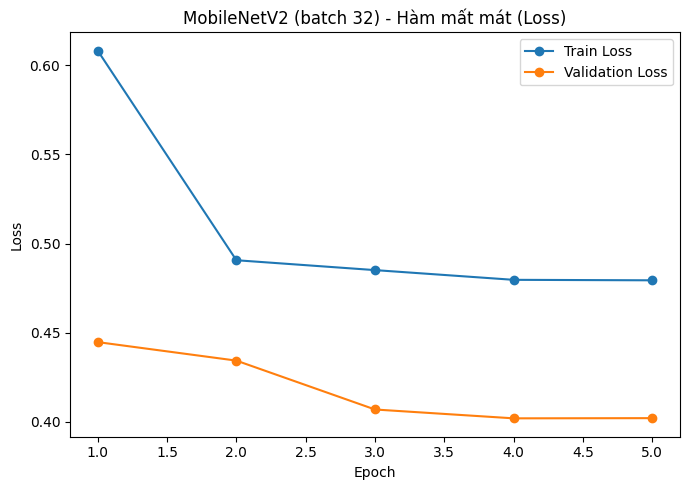

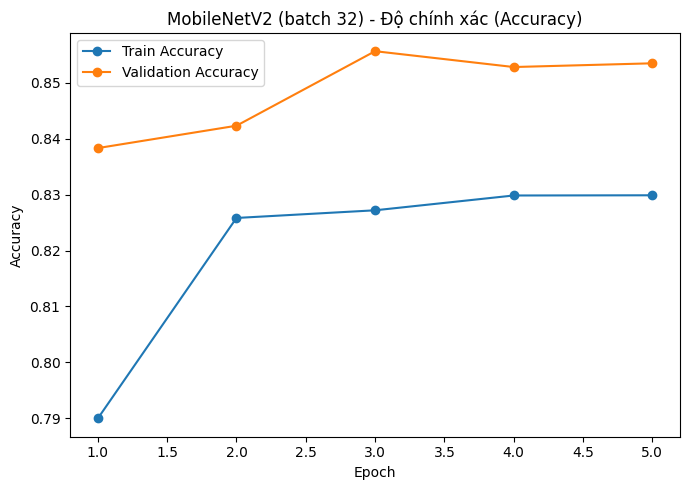

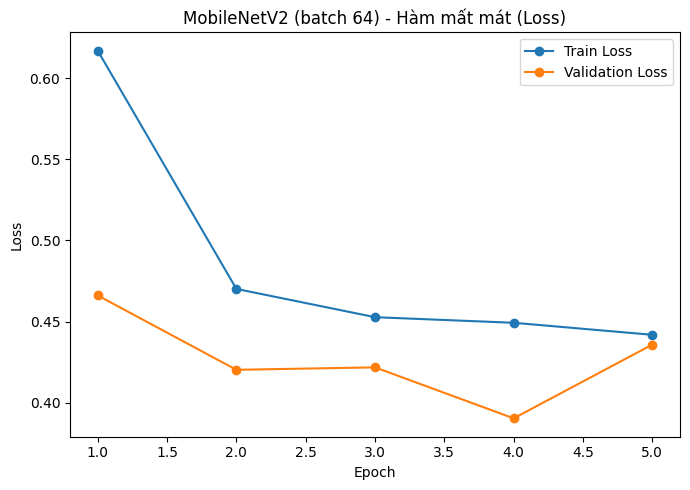

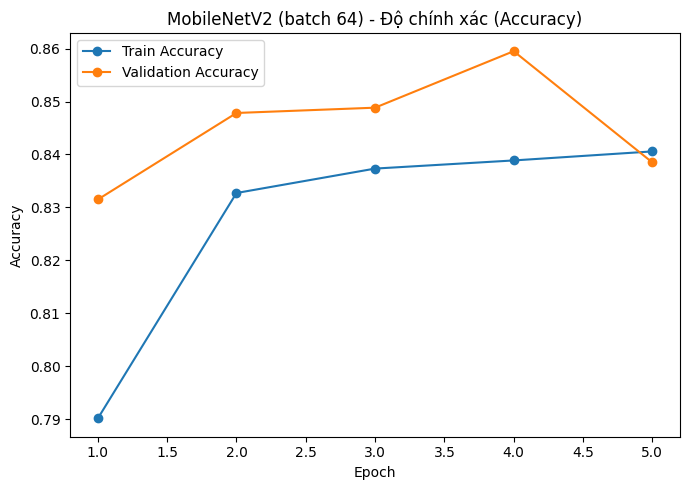

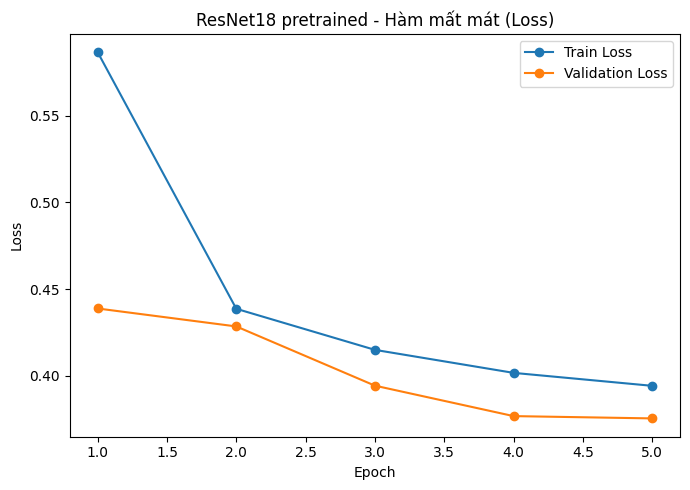

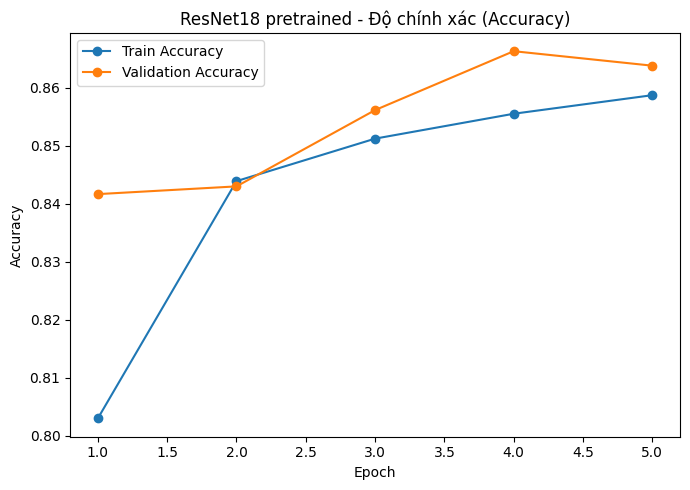

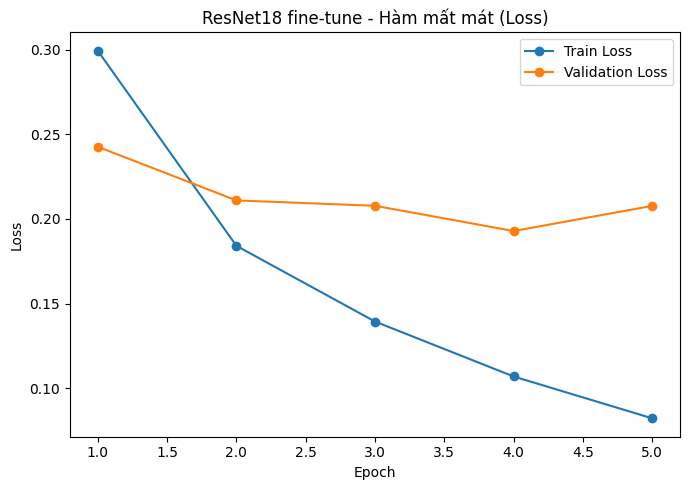

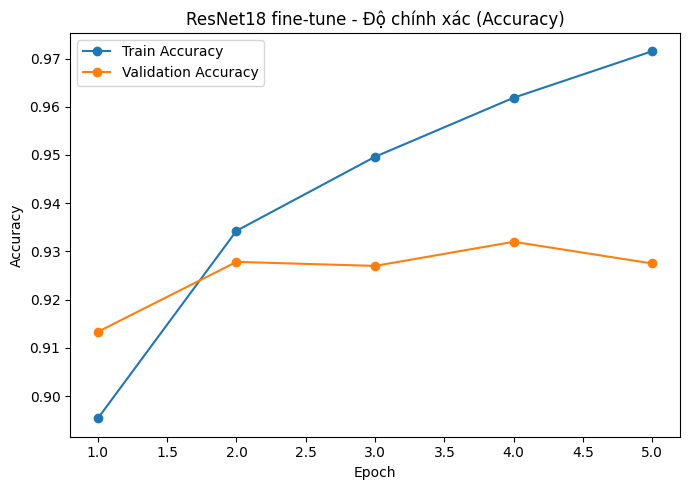

In [3]:
histories = {}
for label, run_dir in RUNS.items():
    history_df = pd.read_csv(run_dir / "metrics" / "history.csv")
    histories[label] = history_df

    fig = plot_loss_curve(history_df, title=f"{label} - Hàm mất mát (Loss)")
    plt.show()

    fig = plot_accuracy_curve(history_df, title=f"{label} - Độ chính xác (Accuracy)")
    plt.show()


## Epoch tốt nhất và kiểm tra overfitting

Với mỗi lần chạy: epoch tốt nhất (validation loss thấp nhất), và khoảng cách giữa
train accuracy và validation accuracy ở epoch cuối (một thước đo đơn giản, dễ giải thích
cho overfitting - khoảng cách càng tăng qua các epoch cho thấy mô hình đang "học thuộc"
dữ liệu huấn luyện).


In [4]:
rows = []
for label, history_df in histories.items():
    final_row = history_df.iloc[-1]
    best_epoch_row = history_df.loc[history_df["val_loss"].idxmin()]
    rows.append({
        "lan_chay": label,
        "epoch_tot_nhat": int(best_epoch_row["epoch"]),
        "val_loss_tot_nhat": best_epoch_row["val_loss"],
        "val_accuracy_tot_nhat": best_epoch_row["val_accuracy"],
        "train_accuracy_cuoi": final_row["train_accuracy"],
        "val_accuracy_cuoi": final_row["val_accuracy"],
        "khoang_cach_train_val_cuoi": final_row["train_accuracy"] - final_row["val_accuracy"],
    })

pd.DataFrame(rows)


,lan_chay,epoch_tot_nhat,val_loss_tot_nhat,val_accuracy_tot_nhat,train_accuracy_cuoi,val_accuracy_cuoi,khoang_cach_train_val_cuoi
0,MobileNetV2 (batch 32),4,0.401926,0.852833,0.829889,0.853500,-0.023611
1,MobileNetV2 (batch 64),4,0.390309,0.859500,0.840574,0.838500,0.002074
2,ResNet18 pretrained,5,0.375544,0.863833,0.858741,0.863833,-0.005093
3,ResNet18 fine-tune,4,0.192874,0.932000,0.971519,0.927500,0.044019


## Nhận xét

- MobileNetV2 batch 32 đạt validation accuracy 85.28% và test accuracy 85.12%.
- Chỉ tăng batch size lên 64 giúp validation accuracy đạt 85.95% và test accuracy
  đạt 85.43%, tăng lần lượt 0.67 và 0.31 điểm phần trăm so với batch 32.
- ResNet18 frozen đạt validation accuracy 86.38% và test accuracy 86.44%, cao hơn
  MobileNetV2 frozen nhưng sử dụng nhiều tham số hơn.
- ResNet18 fine-tune đạt validation accuracy 93.20% và test accuracy 92.87%, cao nhất
  trong các lần chạy của Lab 2. Vì vậy `resnet18/run_003` được
  chọn làm mô hình cuối cùng để phân tích lỗi trong `03_error_analysis.ipynb`.


# Practice 2 - Mạng nơ-ron pretrained và transfer learning

## Thiết kế thí nghiệm

Bốn thí nghiệm dùng cùng FashionMNIST, seed 42, cách chia train/validation 90/10, ảnh
được resize thành 224x224, chuyển từ ảnh xám sang 3 kênh và chuẩn hóa theo ImageNet.
Điểm khác biệt chính là kiến trúc, batch size và phạm vi tham số được cập nhật:

- **MobileNetV2 batch 32:** đóng băng feature extractor, chỉ train classifier 10 lớp.
- **MobileNetV2 batch 64:** giữ nguyên thiết lập trên và chỉ tăng batch size để đo
  ảnh hưởng của siêu tham số này.
- **ResNet18 pretrained:** đóng băng backbone, chỉ train lớp `fc` 10 lớp.
- **ResNet18 fine-tune:** mở khóa `layer4` và `fc`, dùng learning rate nhỏ hơn và data
  augmentation để thích nghi đặc trưng ImageNet với FashionMNIST.

## Khám phá cấu trúc model và tham số

Cell tiếp theo in đầy đủ cấu trúc của từng kiến trúc torchvision và liệt kê các
tensor trainable của từng thí nghiệm, đồng thời tổng hợp tổng số và số tham số trainable.


In [5]:
import json

import yaml

from src.models import build_model

PRACTICE2_RUNS = {
    "MobileNetV2 (batch 32)": PROJECT_ROOT / "runs" / "mobilenet_v2" / "run_002",
    "MobileNetV2 (batch 64)": PROJECT_ROOT / "runs" / "mobilenet_v2" / "run_003",
    "ResNet18 pretrained": PROJECT_ROOT / "runs" / "resnet18" / "run_001",
    "ResNet18 fine-tune": PROJECT_ROOT / "runs" / "resnet18" / "run_003",
}

practice2_records = []
printed_architectures = set()
for label, run_dir in PRACTICE2_RUNS.items():
    with open(run_dir / "config.yaml", "r", encoding="utf-8") as f:
        config = yaml.safe_load(f)
    with open(run_dir / "metrics" / "final_metrics.json", "r", encoding="utf-8") as f:
        metrics = json.load(f)

    model_config = dict(config["model"])
    model_config["pretrained"] = False  # Chỉ dựng kiến trúc, không tải lại weights.
    model = build_model(
        model_config["name"], model_config, config.get("transfer_learning", {})
    )
    total_params = sum(parameter.numel() for parameter in model.parameters())
    trainable_params = sum(
        parameter.numel() for parameter in model.parameters() if parameter.requires_grad
    )
    unfreeze_layers = config.get("transfer_learning", {}).get("unfreeze_layers", [])

    if model_config["name"] not in printed_architectures:
        print(f"\n{'=' * 24} {model_config['name']} {'=' * 24}")
        print(model)
        printed_architectures.add(model_config["name"])

    trainable_names = [
        name for name, parameter in model.named_parameters() if parameter.requires_grad
    ]
    print(f"\n{label} - trainable parameter tensors ({len(trainable_names)}):")
    for parameter_name in trainable_names:
        print(f"  - {parameter_name}")

    practice2_records.append({
        "Thí nghiệm": label,
        "Chiến lược": ("Fine-tune " + ", ".join(unfreeze_layers)) if unfreeze_layers else "Đóng băng backbone",
        "Learning rate": config["training"]["learning_rate"],
        "Batch size": config["training"]["batch_size"],
        "Epochs": config["training"]["epochs"],
        "Augmentation": config["data"].get("augmentation", False),
        "Tổng tham số": total_params,
        "Tham số trainable": trainable_params,
        "Best val accuracy": metrics["best_val_accuracy"],
        "Test accuracy": metrics["test_accuracy"],
    })
    del model

practice2_df = pd.DataFrame(practice2_records)
practice2_df.style.format({
    "Learning rate": "{:.4g}",
    "Best val accuracy": "{:.2%}",
    "Test accuracy": "{:.2%}",
    "Tổng tham số": "{:,}",
    "Tham số trainable": "{:,}",
})



======================== mobilenet_v2 ========================
MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): 


ResNet18 fine-tune - trainable parameter tensors (17):
  - layer4.0.conv1.weight
  - layer4.0.bn1.weight
  - layer4.0.bn1.bias
  - layer4.0.conv2.weight
  - layer4.0.bn2.weight
  - layer4.0.bn2.bias
  - layer4.0.downsample.0.weight
  - layer4.0.downsample.1.weight
  - layer4.0.downsample.1.bias
  - layer4.1.conv1.weight
  - layer4.1.bn1.weight
  - layer4.1.bn1.bias
  - layer4.1.conv2.weight
  - layer4.1.bn2.weight
  - layer4.1.bn2.bias
  - fc.weight
  - fc.bias


,Thí nghiệm,Chiến lược,Learning rate,Batch size,Epochs,Augmentation,Tổng tham số,Tham số trainable,Best val accuracy,Test accuracy
0,MobileNetV2 (batch 32),Đóng băng backbone,0.001,32,5,False,"2,236,682","12,810",85.28%,85.12%
1,MobileNetV2 (batch 64),Đóng băng backbone,0.001,64,5,False,"2,236,682","12,810",85.95%,85.43%
2,ResNet18 pretrained,Đóng băng backbone,0.001,32,5,False,"11,181,642","5,130",86.38%,86.44%
3,ResNet18 fine-tune,"Fine-tune layer4, fc",0.0001,32,5,True,"11,181,642","8,398,858",93.20%,92.87%


## Điều chỉnh kiến trúc cho FashionMNIST

Các weights pretrained ban đầu được học trên ImageNet với 1.000 lớp. Dự án thay đầu
phân loại để đầu ra phù hợp với 10 lớp FashionMNIST:

- MobileNetV2: thay `classifier[1]` bằng `Linear(1280, 10)`.
- ResNet18: thay `fc` bằng `Linear(512, 10)`.
- ResNet18 frozen chỉ cập nhật 5.130 tham số của `fc`; MobileNetV2 frozen cập nhật
  12.810 tham số classifier. Khi fine-tune, ResNet18 cập nhật 8.398.858 tham số thuộc
  `layer4` và `fc`, giúp mô hình thích nghi sâu hơn với miền ảnh thời trang.


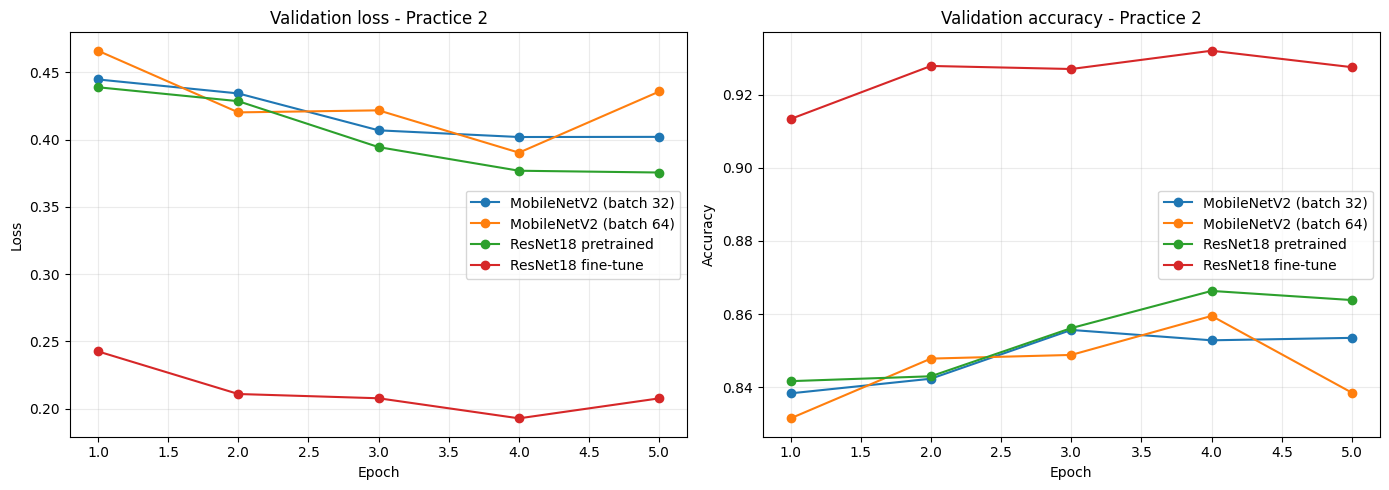

In [6]:
import matplotlib.pyplot as plt

practice2_histories = {
    label: pd.read_csv(run_dir / "metrics" / "history.csv")
    for label, run_dir in PRACTICE2_RUNS.items()
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, history_df in practice2_histories.items():
    axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label=label)
    axes[1].plot(history_df["epoch"], history_df["val_accuracy"], marker="o", label=label)

axes[0].set(title="Validation loss - Practice 2", xlabel="Epoch", ylabel="Loss")
axes[1].set(title="Validation accuracy - Practice 2", xlabel="Epoch", ylabel="Accuracy")
for axis in axes:
    axis.grid(alpha=0.25)
    axis.legend()

plt.tight_layout()
plt.show()


## Kiểm chứng log TensorBoard

Mỗi lần chạy ghi `Loss/train`, `Loss/validation`, `Accuracy/train`,
`Accuracy/validation` và `LearningRate` sau từng epoch. Cell dưới đây đọc trực tiếp
event file để xác nhận cả ba thí nghiệm đều có đủ log giám sát.


In [7]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

tensorboard_records = []
for label, run_dir in PRACTICE2_RUNS.items():
    event_file = next((run_dir / "tensorboard").glob("events.out.tfevents.*"))
    accumulator = EventAccumulator(str(event_file))
    accumulator.Reload()
    scalar_tags = accumulator.Tags()["scalars"]
    tensorboard_records.append({
        "Thí nghiệm": label,
        "Số epoch đã ghi": len(accumulator.Scalars("Loss/train")),
        "Scalar tags": ", ".join(scalar_tags),
    })

pd.DataFrame(tensorboard_records)


,Thí nghiệm,Số epoch đã ghi,Scalar tags
0,MobileNetV2 (batch 32),5,"Loss/train, Loss/validation, Accuracy/train, A..."
1,MobileNetV2 (batch 64),5,"Loss/train, Loss/validation, Accuracy/train, A..."
2,ResNet18 pretrained,5,"Loss/train, Loss/validation, Accuracy/train, A..."
3,ResNet18 fine-tune,5,"Loss/train, Loss/validation, Accuracy/train, A..."


## Kết luận Practice 2

- MobileNetV2 batch 32 đạt **85.28% best validation accuracy** và **85.12% test
  accuracy**. Đây là baseline nhẹ với 2.236.682 tham số và 12.810 tham số trainable.
- MobileNetV2 batch 64 đạt **85.95% best validation accuracy** và **85.43% test
  accuracy**, tăng lần lượt 0,67 và 0,31 điểm phần trăm. Cải thiện là nhỏ; validation
  loss tăng lại ở epoch 5 nên checkpoint epoch 4 được giữ.
- ResNet18 frozen đạt **86.44%**, cao hơn MobileNetV2 1,32 điểm phần trăm nhưng vẫn bị
  giới hạn vì backbone ImageNet chưa thích nghi với ảnh FashionMNIST.
- ResNet18 fine-tune đạt **93.20% best validation accuracy** và **92.87% test accuracy**.
  Kết quả test tăng 6,43 điểm phần trăm so với ResNet18 frozen, xác nhận việc mở khóa
  `layer4` và dùng learning rate 0.0001 là hiệu quả.
- Ở epoch cuối, khoảng cách train/validation accuracy của fine-tune khoảng 4,40 điểm
  phần trăm, cho thấy overfitting nhẹ. Checkpoint epoch 4 được chọn theo validation loss
  thấp nhất để hạn chế ảnh hưởng này.

**Mô hình được chọn:** `resnet18/run_003`, vì có validation và test accuracy cao nhất.
